## Loading Data - Jon/Brock's Code

In [9]:
# %%
import pandas as pd
import numpy as np
from scipy.optimize import minimize
from typing import Tuple
import matplotlib.pyplot as plt

# %% [markdown]
# ## Load and Clean Corporate Bond Data

# %%
df = pd.read_excel("../data/cleaneddata.xlsx")
df.columns = df.columns.str.strip()

df["date"] = pd.to_datetime(df["date"], errors="coerce")
df = df.sort_values(["cusip","date"])

for col in ["spread","price","sduration","coupon","ytm"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df = df.dropna(subset=["date","spread","price","sduration"])
df["spread"] = df["spread"] / 10000.0

df["ym"] = df["date"].dt.to_period("M") #type:ignore

# %% [markdown]
# ## Build Monthly Panel and Compute Returns and DTS

# %%

def get_first_day(data = df):
    price_col = "price"

    first_day = (
        data.sort_values("date")
        .groupby(["cusip","ym"])
        .first()
        .reset_index()
    )

    # next month price + next month label
    first_day["next_price"] = first_day.groupby("cusip")[price_col].shift(-1)
    first_day["next_ym"]    = first_day.groupby("cusip")["ym"].shift(-1)

    first_day = first_day.dropna(subset=["next_price","next_ym"])

    first_day["price_ret"] = (
        (first_day["next_price"] - first_day[price_col]) /
        first_day[price_col]
    )

    # carry = coupon%/12 / price
    first_day["carry"] = ((first_day["coupon"] / 100) / 12) / first_day[price_col]

    # total return
    first_day["ret"] = first_day["price_ret"] + first_day["carry"]

    # DTS (for sorting into buckets; scaling doesn't affect order)
    first_day["dts"] = first_day["spread"] * first_day["sduration"]

    # wide monthly return matrix
    ret_pivot = (
    first_day.pivot(index="ym", columns="cusip", values="ret")
    .sort_index()
)

    return first_day, ret_pivot

first_day, ret_pivot = get_first_day()

# %% [markdown]
# ## Portfolio Optimizer (Long-Only Maximum Sharpe Ratio)

# %%

def optimize_weights_dts(mu, cov, w_max=0.05):
    """Maximize Sharpe ratio with weight caps (long-only)."""
    n = len(mu)
    w0 = np.ones(n) / n

    def neg_sharpe(w):
        ret = np.dot(w, mu)
        vol = np.sqrt(np.dot(w.T, np.dot(cov, w)))
        if vol <= 0:
            return 1e9
        return -(ret / vol)

    bounds = [(0, w_max)] * n
    cons = [{"type": "eq", "fun": lambda w: np.sum(w) - 1}]

    res = minimize(
        neg_sharpe, w0,
        method="SLSQP",
        bounds=bounds,
        constraints=cons,
        options={"maxiter": 500, "ftol": 1e-9}
    )

    return res.x

def optimize_duration_neutral(mu, cov, sdur, w_max=0.10):
    n = len(mu)
    w0 = np.ones(n) / n

    def neg_sharpe(w):
        ret = np.dot(w, mu)
        vol = np.sqrt(np.dot(w.T, np.dot(cov, w)))
        if vol <= 0:
            return 1e9
        return -(ret / vol)

    bounds = [(-w_max, w_max)] * n

    cons = [
        {"type": "eq", "fun": lambda w: np.sum(w) - 1},
        {"type": "eq", "fun": lambda w: np.dot(w, sdur)}  # duration = 0
    ]

    res = minimize(
        neg_sharpe,
        w0,
        method="SLSQP",
        bounds=bounds,
        constraints=cons,
        options={"maxiter": 1000, "ftol": 1e-9}
    )

    if not res.success:
        return w0

    return res.x

# %% [markdown]
# ## Build Unhedged Portfolios

def speed_run_dts(first_day, ret_pivot,treasury):
    # %%
    port_low  = []
    port_mid  = []
    port_high = []

    weights_list_low = []
    weights_list_mid = []
    weights_list_high = []

    months = sorted(first_day["ym"].unique())

    for idx in range(3, len(months)):
        ym = months[idx]

        # trailing 3 months for mean/cov estimation
        window = months[idx-3:idx]
        hist = ret_pivot.loc[window]

        # current month bonds
        month_df = first_day[first_day["ym"] == ym].copy()
        month_df = month_df.sort_values("dts")
        n = len(month_df)
        if n < 6:
            continue

        # split into 3 equal DTS buckets
        k = n // 3
        low  = month_df.iloc[:k].copy()
        mid  = month_df.iloc[k:2*k].copy()
        high = month_df.iloc[2*k:3*k].copy()


        # helper
        def prepare_bucket(bucket):
            cus = list(bucket["cusip"])
            sub = hist[cus].dropna(axis=1, how="any")

            if sub.shape[1] < 2:
                return None, None, None

            cusips = list(sub.columns)
            bucket_ordered = bucket.set_index("cusip").loc[cusips].reset_index()

            mu  = sub.mean().values
            cov = np.cov(sub.T)

            return bucket_ordered, mu, cov

        # prepare each
        low_b,  mu_low,  cov_low  = prepare_bucket(low)
        mid_b,  mu_mid,  cov_mid  = prepare_bucket(mid)
        high_b, mu_high, cov_high = prepare_bucket(high)

        if low_b is None or mid_b is None or high_b is None:
            continue

        # optimize
        w_low  = optimize_weights_dts(mu_low,  cov_low)
        w_mid  = optimize_weights_dts(mu_mid,  cov_mid)
        w_high = optimize_weights_dts(mu_high, cov_high)

        # realized return
        ret_low  = np.dot(w_low,  low_b["ret"].values)
        ret_mid  = np.dot(w_mid,  mid_b["ret"].values)
        ret_high = np.dot(w_high, high_b["ret"].values)

        # portfolio sduration (for Treasury hedge)
        dur_low  = np.dot(w_low,  low_b["sduration"].values)
        dur_mid  = np.dot(w_mid,  mid_b["sduration"].values)
        dur_high = np.dot(w_high, high_b["sduration"].values)

        # Getting weights
        weights_list_low.append(
            pd.Series(w_low, index=list(low_b["cusip"]), name = ym.to_timestamp())
        )
        weights_list_mid.append(
            pd.Series(w_mid, index=list(mid_b["cusip"]), name = ym.to_timestamp())
        )

        weights_list_high.append(
            pd.Series(w_high, index=list(high_b["cusip"]), name = ym.to_timestamp())
        )

        # append
        port_low.append({
            "month": ym,
            "ret": ret_low,
            "dur_p": dur_low,
            "cusips": list(low_b["cusip"]),
        })

        port_mid.append({
            "month": ym,
            "ret": ret_mid,
            "dur_p": dur_mid,
            "cusips": list(mid_b["cusip"]),
        })

        port_high.append({
            "month": ym,
            "ret": ret_high,
            "dur_p": dur_high,
            "cusips": list(high_b["cusip"]),
        })

    low_opt  = pd.DataFrame(port_low)
    mid_opt  = pd.DataFrame(port_mid)
    high_opt = pd.DataFrame(port_high)

    weights_low = pd.DataFrame(weights_list_low)
    weights_mid = pd.DataFrame(weights_list_mid)
    weights_high = pd.DataFrame(weights_list_high)

    # cumulative returns (unhedged)
    low_opt["cum_ret"]  = (1 + low_opt["ret"]).cumprod() - 1
    mid_opt["cum_ret"]  = (1 + mid_opt["ret"]).cumprod() - 1
    high_opt["cum_ret"] = (1 + high_opt["ret"]).cumprod() - 1

    # print("LOW DTS (unhedged):")
    # print(low_opt.tail(), "\n")

    # print("MID DTS (unhedged):")
    # print(mid_opt.tail(), "\n")

    # print("HIGH DTS (unhedged):")
    # print(high_opt.tail(), "\n")

    # %% [markdown]
    # ## Load Treasury Returns

    # %%
    treasury["ym"] = treasury["ym"].astype("period[M]")
    treasury = treasury.set_index("ym").sort_index()

    # Assume a constant Treasury duration (e.g. IEF ~ 7.5 years)
    duration_T = 7.5

    # %% [markdown]
    # ## Merge Portfolios with Treasury and Compute Hedge

    # %%
    for df_opt in [low_opt, mid_opt, high_opt]:
        df_opt["ym"] = df_opt["month"]
        df_opt.set_index("ym", inplace=True)

    # Join Treasury returns
    low_opt  = low_opt.join(treasury, how="inner")
    mid_opt  = mid_opt.join(treasury, how="inner")
    high_opt = high_opt.join(treasury, how="inner")

    # Hedge ratios: theta_T = -Dur_portfolio / Dur_Treasury
    low_opt["theta_T"]  = -low_opt["dur_p"]  / duration_T
    mid_opt["theta_T"]  = -mid_opt["dur_p"]  / duration_T
    high_opt["theta_T"] = -high_opt["dur_p"] / duration_T

    # Duration-hedged returns
    low_opt["Duration Hedged \n (Treasuries)"]  = low_opt["ret"]  + low_opt["theta_T"] * low_opt["ret_T"]
    mid_opt["Duration Hedged \n (Treasuries)"]  = mid_opt["ret"]  + mid_opt["theta_T"] * mid_opt["ret_T"]
    high_opt["Duration Hedged \n (Treasuries)"] = high_opt["ret"] + high_opt["theta_T"] * high_opt["ret_T"]

    # Cumulative duration-hedged returns
    low_opt["Cum Duration Hedged \n (Treasuries)"]  = (1 + low_opt["Duration Hedged \n (Treasuries)"]).cumprod() - 1
    mid_opt["Cum Duration Hedged \n (Treasuries)"]  = (1 + mid_opt["Duration Hedged \n (Treasuries)"]).cumprod() - 1
    high_opt["Cum Duration Hedged \n (Treasuries)"] = (1 + high_opt["Duration Hedged \n (Treasuries)"]).cumprod() - 1

    return {
        "weights": {
            "low": weights_low,
            "mid": weights_mid,
            "high": weights_high
        },
        "returns": {
            "low": low_opt,
            "mid": mid_opt,
            "high": high_opt
        }
    }
    

### Duration Hedge

In [10]:
def speed_run_dur(first_day, ret_pivot, cdx):
    dn_low  = []
    dn_mid  = []
    dn_high = []

    weights_list_low_dn = []
    weights_list_mid_dn = []
    weights_list_high_dn = []

    months = sorted(first_day["ym"].unique())

    for idx in range(3, len(months)):
        ym = months[idx]

        # trailing 3 months for mean/cov estimation
        window = months[idx-3:idx]
        hist = ret_pivot.loc[window]

        # current month bonds
        month_df = first_day[first_day["ym"] == ym].copy()
        month_df = month_df.sort_values("dts")
        n = len(month_df)
        if n < 6:
            continue

        # split into 3 equal DTS buckets
        k = n // 3
        low  = month_df.iloc[:k].copy()
        mid  = month_df.iloc[k:2*k].copy()
        high = month_df.iloc[2*k:3*k].copy()

        def prep(bucket):
            # align bucket cusips with historical return matrix
            cus = list(bucket["cusip"])
            sub = hist[cus].dropna(axis=1, how="any")
            if sub.shape[1] < 2:
                return None, None, None

            cusips = list(sub.columns)
            bucket2 = bucket.set_index("cusip").loc[cusips].reset_index()

            mu  = sub.mean().values
            cov = np.cov(sub.T)

            return bucket2, mu, cov

        low_b,  mu_low,  cov_low  = prep(low)
        mid_b,  mu_mid,  cov_mid  = prep(mid)
        high_b, mu_high, cov_high = prep(high)

        if low_b is None or mid_b is None or high_b is None:
            continue

        # spread-duration arrays
        sdur_low  = low_b["sduration"].values
        sdur_mid  = mid_b["sduration"].values
        sdur_high = high_b["sduration"].values

        # duration-neutral weights (using only corporates)
        w_low  = optimize_duration_neutral(mu_low,  cov_low,  sdur_low)
        w_mid  = optimize_duration_neutral(mu_mid,  cov_mid,  sdur_mid)
        w_high = optimize_duration_neutral(mu_high, cov_high, sdur_high)

        # realized corporate-only return (no external hedge yet)
        ret_low  = np.dot(w_low,  low_b["ret"].values)
        ret_mid  = np.dot(w_mid,  mid_b["ret"].values)
        ret_high = np.dot(w_high, high_b["ret"].values)

        # portfolio DTS exposure (for CDX hedge)
        dts_low  = np.dot(w_low,  low_b["dts"].values)
        dts_mid  = np.dot(w_mid,  mid_b["dts"].values)
        dts_high = np.dot(w_high, high_b["dts"].values)

        # Getting Weights
        weights_list_low_dn.append(
            pd.Series(w_low, index=list(low_b["cusip"]), name = ym.to_timestamp())
        )
        weights_list_mid_dn.append(
            pd.Series(w_mid, index=list(mid_b["cusip"]), name = ym.to_timestamp())
        )

        weights_list_high_dn.append(
            pd.Series(w_high, index=list(high_b["cusip"]), name = ym.to_timestamp())
        )

        dn_low.append({
            "month": ym,
            "ret_dn": ret_low,
            "dts_p": dts_low
        })

        dn_mid.append({
            "month": ym,
            "ret_dn": ret_mid,
            "dts_p": dts_mid
        })

        dn_high.append({
            "month": ym,
            "ret_dn": ret_high,
            "dts_p": dts_high
        })

    low_opt_dn  = pd.DataFrame(dn_low)
    mid_opt_dn  = pd.DataFrame(dn_mid)
    high_opt_dn = pd.DataFrame(dn_high)

    weights_low_dn = pd.DataFrame(weights_list_low_dn)
    weights_mid_dn = pd.DataFrame(weights_list_low_dn)
    weights_high_dn = pd.DataFrame(weights_list_low_dn)

    # cumulative returns for duration-neutral portfolios (no CDX hedge yet)
    low_opt_dn["cum_dn"]  = (1 + low_opt_dn["ret_dn"]).cumprod() - 1
    mid_opt_dn["cum_dn"]  = (1 + mid_opt_dn["ret_dn"]).cumprod() - 1
    high_opt_dn["cum_dn"] = (1 + high_opt_dn["ret_dn"]).cumprod() - 1

    # basic cleaning
    cdx["date"] = pd.to_datetime(cdx["date"], errors="coerce")
    cdx["spread_bps"] = pd.to_numeric(cdx["spread_bps"], errors="coerce")

    # filter to US_IG 5Y only (one index)
    cdx = cdx[(cdx["index_name"] == "US_IG") & (cdx["tenor"] == "5Y")].copy()

    # convert to monthly (take last spread of each month)
    cdx["ym"] = cdx["date"].dt.to_period("M")
    cdx_m = (
        cdx.sort_values("date")
            .groupby("ym")
            .tail(1)    # last obs in month
            .set_index("ym")
            .sort_index()
    )

    # convert spread to decimal (e.g., 81.25 bps => 0.008125)
    cdx_m["spread"] = cdx_m["spread_bps"] / 10000.0

    # assume a constant CDX index duration (rough approximation)
    duration_cdx = 5.0  # you can refine this if you have better data

    # approximate monthly CDX 'price return' via -Duration * ΔSpread
    cdx_m["delta_spread"] = cdx_m["spread"].diff()
    cdx_m["ret_cdx"] = -duration_cdx * cdx_m["delta_spread"]

    # DTS of one unit notional of CDX each month
    cdx_m["dts_cdx"] = cdx_m["spread"] * duration_cdx

    # drop first month with NaN ret_cdx
    cdx_m = cdx_m.dropna(subset=["ret_cdx", "dts_cdx"])

    # keep only needed columns
    cdx_m = cdx_m[["ret_cdx", "dts_cdx"]]

    for df_opt in [low_opt_dn, mid_opt_dn, high_opt_dn]:
        df_opt["ym"] = df_opt["month"]
        df_opt.set_index("ym", inplace=True)

    # join CDX monthly returns & DTS
    low_opt  = low_opt_dn.join(cdx_m, how="inner")
    mid_opt  = mid_opt_dn.join(cdx_m, how="inner")
    high_opt = high_opt_dn.join(cdx_m, how="inner")

    # hedge ratios based on DTS: theta_cdx_t = - DTS_portfolio_t / DTS_CDX_t
    low_opt["theta_cdx"]  = - low_opt["dts_p"]  / low_opt["dts_cdx"]
    mid_opt["theta_cdx"]  = - mid_opt["dts_p"]  / mid_opt["dts_cdx"]
    high_opt["theta_cdx"] = - high_opt["dts_p"] / high_opt["dts_cdx"]

    # hedged returns: duration-neutral corporate + CDX overlay (DTS-neutral)
    low_opt["ret_dn_hedged"]  = low_opt["ret_dn"]  + low_opt["theta_cdx"] * low_opt["ret_cdx"]
    mid_opt["ret_dn_hedged"]  = mid_opt["ret_dn"]  + mid_opt["theta_cdx"] * mid_opt["ret_cdx"]
    high_opt["ret_dn_hedged"] = high_opt["ret_dn"] + high_opt["theta_cdx"] * high_opt["ret_cdx"]

    # cumulative hedged returns
    low_opt["cum_dn_hedged"]  = (1 + low_opt["ret_dn_hedged"]).cumprod() - 1
    mid_opt["cum_dn_hedged"]  = (1 + mid_opt["ret_dn_hedged"]).cumprod() - 1
    high_opt["cum_dn_hedged"] = (1 + high_opt["ret_dn_hedged"]).cumprod() - 1

    # Renaming columns
    renamed_dict = {
        "ret_dn": "Unhedged",
        "cum_dn": "Cum Unhedged",
        "ret_dn_hedged" : "DTS Hedged \n (CDX)",
        "cum_dn_hedged" : "Cum DTS Hedged \n (CDX)"
    }

    return {
        "weights": {
            "low": weights_low_dn,
            "mid":  weights_mid_dn,
            "high":weights_high_dn,
        },
        "returns" :{
            "low": low_opt.rename(columns = renamed_dict),
            "mid":  mid_opt.rename(columns = renamed_dict),
            "high": high_opt.rename(columns = renamed_dict),
        }, 
    }

# Historical Stress
First looking at Covid and then using Block Bootstrapping to get multiple samples and create more calculations on risk metrics

In [11]:
treasury = pd.read_csv("../data/treasury_data.csv")
cdx = pd.read_csv("../data/cdx_all_us_cleaned.csv")

In [12]:
# February 2020 - April 2022 (monthly frequency)
covid_stress_period = slice("2020-02", "2022-04")
covid_stress_hist= ret_pivot.loc[covid_stress_period]

dts_speed = speed_run_dts(first_day=first_day, ret_pivot=ret_pivot,treasury=treasury)
dur_speed = speed_run_dur(first_day=first_day, ret_pivot=ret_pivot,cdx=cdx)

returns = {
    "dts": dts_speed["returns"],
    "dur": dur_speed["returns"]
}

In [13]:
cols_to_query = ["Duration Hedged \n (Treasuries)", 
                 "Cum Duration Hedged \n (Treasuries)", 

                 "Unhedged", 
                 "Cum Unhedged",
                 
                 "DTS Hedged \n (CDX)",
                 "Cum DTS Hedged \n (CDX)"
                 ]

/var/folders/49/1jq9sd950fg6397s7sm972380000gn/T/ipykernel_81942/531055136.py:38: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


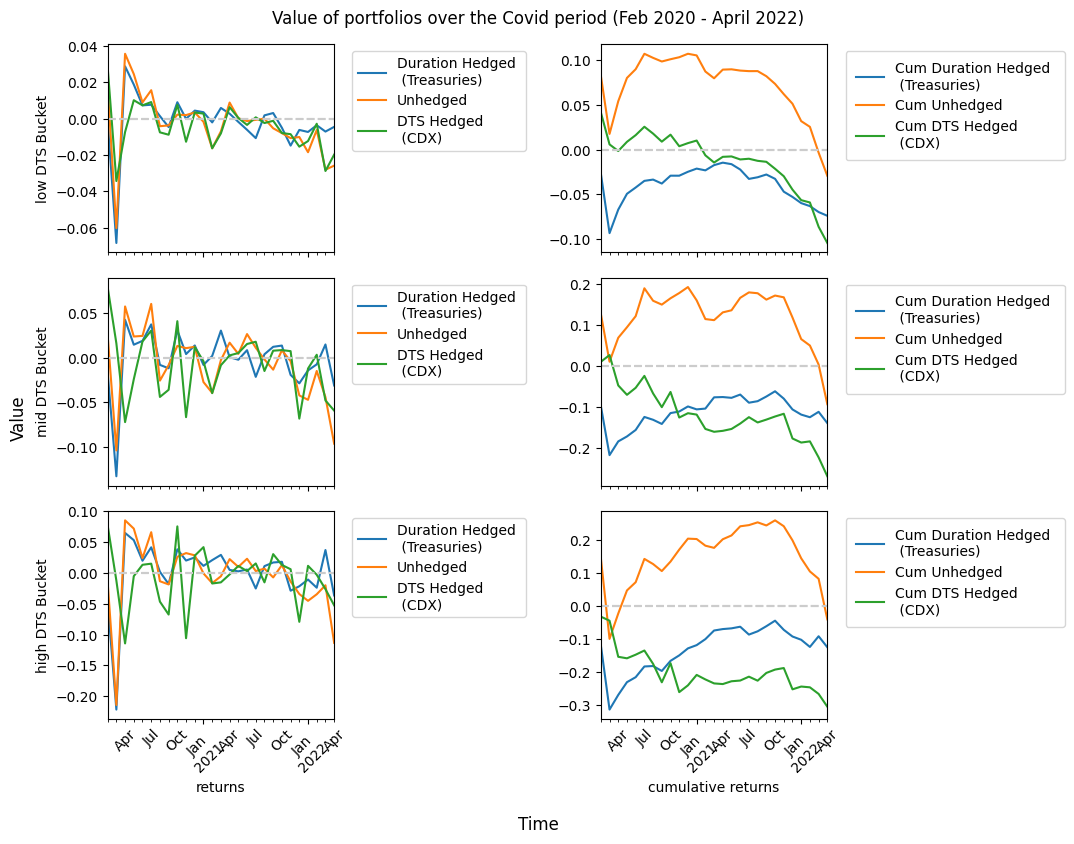

In [14]:
fig, ax = plt.subplots(3, 2, sharex=True, sharey=False, figsize = (11,8.5))

for j, (port_hedge, returns_hedge) in enumerate(returns.items()):
    for i, (port_style, returns_style) in enumerate(returns_hedge.items()):

        # getting Columns
        cols = [c for c in returns_style.columns if c in cols_to_query]
        new_df = returns_style[cols].loc[covid_stress_period]

        returns_cols = [c for c in new_df if not c.startswith("Cum")]
        cum_cols = [c for c in new_df if  c.startswith("Cum")]

        new_df[returns_cols].plot(ax= ax[i,0], rot = 45)
        ax[i,0].set_xlabel("returns")

        new_df[cum_cols].plot(ax= ax[i,1], rot = 45)
        ax[i,1].set_xlabel("cumulative returns")

        ax[i,0].set_ylabel(f"{port_style} DTS Bucket")

        #adding horizontal lines at 0
        ax[i,0].hlines(0, new_df.index.min(), new_df.index.max(), colors=".8", linestyles="dashed")
        ax[i,1].hlines(0, new_df.index.min(), new_df.index.max(), colors=".8", linestyles="dashed")

        ax[i,0].legend(
            bbox_to_anchor=(1.05, 1),
            loc='upper left'
        )
        ax[i,1].legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderpad = .75)


fig.supxlabel("Time")
fig.supylabel("Value")

fig.suptitle("Value of portfolios over the Covid period (Feb 2020 - April 2022)")

fig.tight_layout()
fig.show()

/var/folders/49/1jq9sd950fg6397s7sm972380000gn/T/ipykernel_81942/2275156237.py:36: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


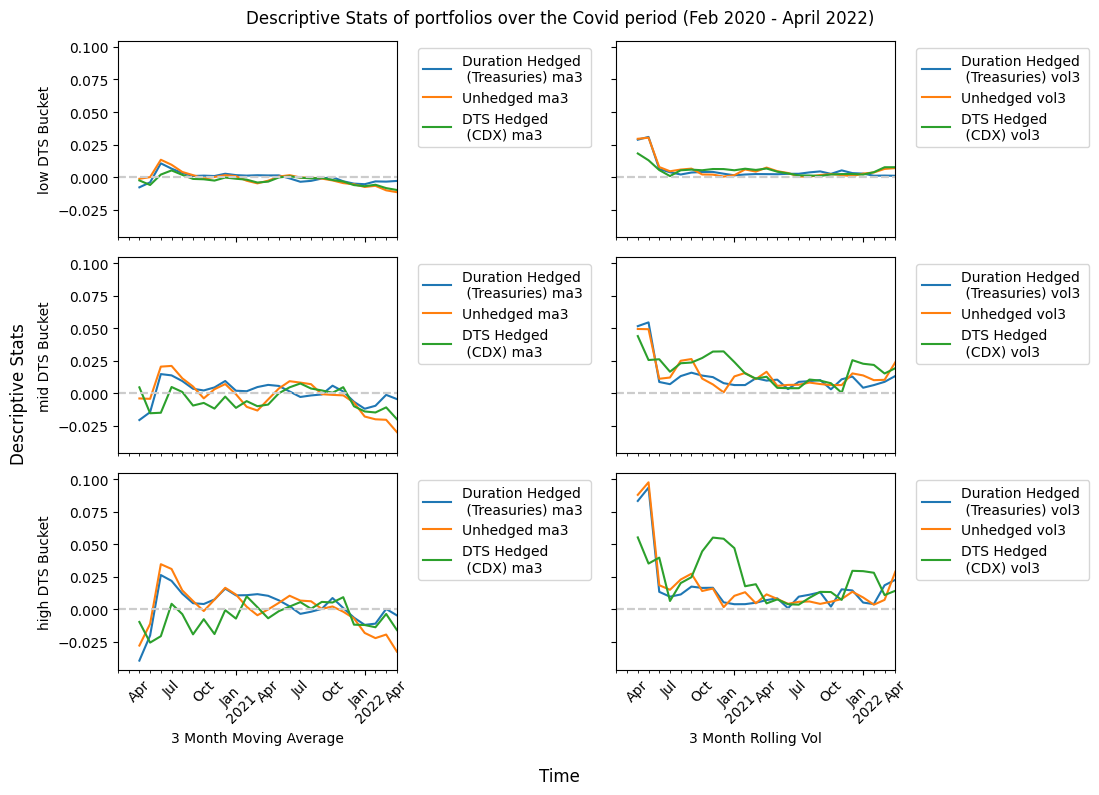

In [15]:
fig, ax = plt.subplots(3, 2, sharex=True, sharey=True, figsize = (11,8))

for j, (port_hedge, returns_hedge) in enumerate(returns.items()):
    for i, (port_style, returns_style) in enumerate(returns_hedge.items()):

        # getting Columns
        cols = [c for c in returns_style.columns if c in cols_to_query]
        new_df = returns_style[cols].loc[covid_stress_period]

        returns_cols = [c for c in new_df if not c.startswith("Cum")]

        for col in returns_cols:
            new_df[f"{col} ma3"] = new_df[col].rolling(3).mean()/np.sqrt(3)
            new_df[f"{col} vol3"] = new_df[col].rolling(3).std()/np.sqrt(3)

            new_df[f"{col} ma3"].plot(ax=ax[i,0], rot = 45)
            new_df[f"{col} vol3"].plot(ax=ax[i,1], rot = 45)

        ax[i,j].set_ylabel(f"{port_style} DTS Bucket")

        # Set the x-axis label
        ax[i,0].set_xlabel("3 Month Moving Average")
        ax[i,1].set_xlabel("3 Month Rolling Vol")

        ax[i,0].legend(bbox_to_anchor=(1.05, 1), loc='upper left', markerscale = .6)
        ax[i,1].legend(bbox_to_anchor=(1.05, 1), loc='upper left', markerscale = .6)
        ax[i,0].hlines(0, new_df.index.min(), new_df.index.max(), colors=".8", linestyles="dashed")
        ax[i,1].hlines(0, new_df.index.min(), new_df.index.max(), colors=".8", linestyles="dashed")


fig.supxlabel("Time")
fig.supylabel("Descriptive Stats", x=.0001)

fig.suptitle("Descriptive Stats of portfolios over the Covid period (Feb 2020 - April 2022)")
fig.tight_layout()
fig.show()

In [16]:
def block_bootstrap(data:list,num_blocks:int, num_iterations:int):
    block_indices = np.random.choice(data[0].shape[0], size=(num_blocks, 2 , num_iterations))
    simulations = []

    block_indices.sort(axis=1)

    for i in range(num_iterations):
        start_indices , end_indices = block_indices[:,0, i], block_indices[:,1, i]

        data_set_holder = []
        
        for k, data_set in enumerate(data):
            #creating a holder for each dataset to then concatenate into one dataframe
            holder = []
            for j in range(num_blocks):
                holder.append(data_set.iloc[start_indices[j]: end_indices[j], :])

            data_set_holder.append(pd.concat(holder))

        simulations.append(data_set_holder)



    return simulations

In [17]:
simulations = block_bootstrap(data = [ret_pivot_covid, treasury.loc[covid_stress_period], cdx.loc[covid_stress_period]],num_blocks= 7,num_iterations = 100)
            
losses = []

for i, simulation in enumerate(simulations):
    ret_pivot_sim, treasury_sim, cdx_sim = simulation

    dts_dict =speed_run_dts(None, ret_pivot_sim, treasury_sim)
    dur_dict =speed_run_dur(first_day_sim, ret_pivot_sim, cdx_sim)

    print(dts_dict["returns"])


    break

NameError: name 'ret_pivot_covid' is not defined